# CDNOTS vs CDNOTS+: When Does the Second Phase Help?

**CDNOTS** discovers causal structure using a PC-style skeleton: it iterates over all pairs of variables at increasing conditioning-set depth until no more edges can be removed. At deep levels, pairs adjacent to hub nodes generate enormous conditioning sets — tens of thousands of combinations — that collapse statistical power and cause true edges to be incorrectly removed.

**CDNOTS+** addresses this with a two-phase MCI approach (inspired by PCMCI+): phase 1 finds a parent superset for each variable; phase 2 re-tests each edge conditioning *only on the discovered parents*, not on all neighbors. This restores power at high-degree hubs.

We benchmarked both algorithms across three graph topologies, three density regimes, four graph sizes (midsize and large) and four sample sizes. This notebook presents the key findings.

**Key messages:**
- `alpha=0.01` is required — at `alpha=0.05` CDNOTS+ is net negative
- CDNOTS+ helps **scale-free (hub) graphs**, not Erdős–Rényi or small-world
- The improvement comes from **recovering true edges** (↑ TPR), not removing false ones
- Hub degree drives the effect: higher max-degree → more benefit

In [19]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from tqdm.auto import tqdm

from causalts import run_cdnots, run_cdnots_plus
from causalts.ci_tests.parcorr_gpu import ParCorrGPU
from causalts.synthetic_data.synthetic_datasets import topology_scp
from causalts.utils import evaluate_graph

DEVICE = 'cpu'   # change to 'cuda' if available
ALPHA  = 0.01    # always use 0.01 with CDNOTS+

## The three graph families

We tested three canonical topologies that represent very different degree distributions:

| Topology | Structure | Degree distribution | Hub effect |
|---|---|---|---|
| **Scale-free** (Barabási–Albert) | Hub-and-spoke | Heavy-tailed (power law) | Strong |
| **Erdős–Rényi** | Random uniform edges | Poisson (homogeneous) | None |
| **Small-world** (Watts–Strogatz) | Clustered ring | Narrow (bounded by k) | Mild |

The scale-free topology is where conditioning sets at depth 3–5 grow catastrophically large at hub nodes.

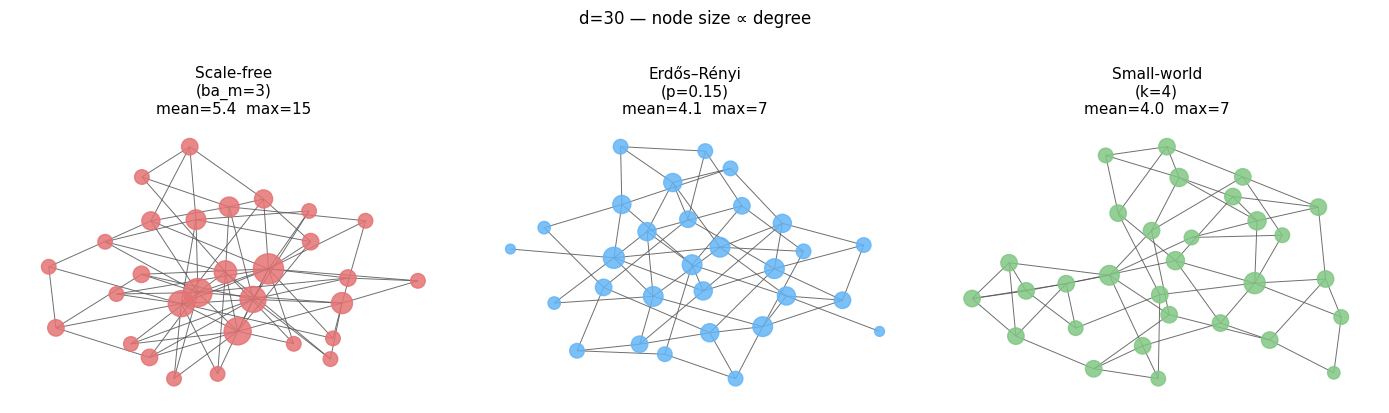

In [40]:
n = 30
graphs = {
    'Scale-free\n(ba_m=3)':  nx.barabasi_albert_graph(n, 3, seed=42),
    'Erdős–Rényi\n(p=0.15)': nx.erdos_renyi_graph(n, 0.15, seed=42),
    'Small-world\n(k=4)':    nx.watts_strogatz_graph(n, 4, 0.3, seed=42),
}
topo_palette = ['#E57373', '#64B5F6', '#81C784']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (title, G), color in zip(axes, graphs.items(), topo_palette):
    pos = nx.nx_agraph.graphviz_layout(G, prog='neato')
    degs = dict(G.degree())
    nx.draw(G, pos, ax=ax,
            node_color=color,
            node_size=[20 + 30 * degs[v] for v in G.nodes()],
            edge_color='#555', width=0.7, alpha=0.85, with_labels=False)
    ax.set_title(
        f'{title}\nmean={np.mean(list(degs.values())):.1f}  '
        f'max={max(degs.values())}', fontsize=11
    )
plt.suptitle('d=30 — node size ∝ degree', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Finding 1 — Alpha = 0.01 is required

At `alpha=0.05`, the skeleton retains too many spurious edges. CDNOTS+ phase 1 then discovers inflated parent sets, and phase 2 re-tests against those noisy parents — worsening the result.

At `alpha=0.01`, the skeleton is clean enough for phase 1 parent estimation to be reliable, and CDNOTS+ recovers true edges the plain PC skeleton missed.

**Confirmed over 10 seeds, d=15–50, all topologies:**

| Alpha | CDNOTS F1 | CDNOTS+ F1 | Gap |
|---|---|---|---|
| 0.05 | 0.752 | 0.709 | **−0.043** |
| **0.01** | **0.785** | **0.812** | **+0.027** |

alpha=0.05:   0%|          | 0/3 [00:00<?, ?it/s]

alpha=0.01:   0%|          | 0/3 [00:00<?, ?it/s]

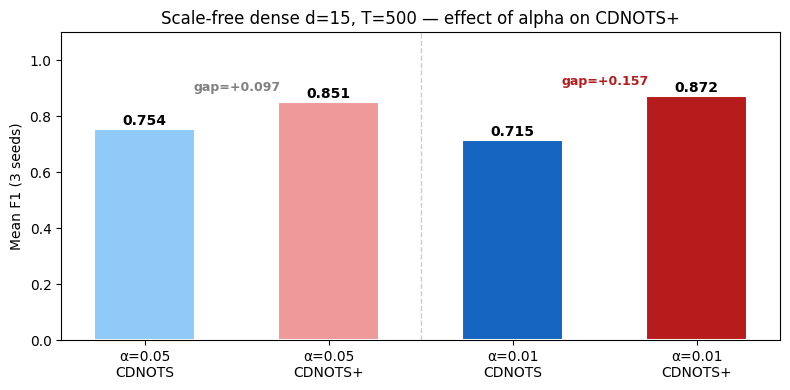

In [11]:
# Alpha effect on scale-free dense d=15, T=500, 3 seeds
SEEDS = [0, 1, 2]
alpha_results = {(a, m): [] for a in [0.05, 0.01] for m in ['CDNOTS', 'CDNOTS+']}

for alpha in [0.05, 0.01]:
    for seed in tqdm(SEEDS, desc=f'alpha={alpha}', leave=False):
        ds = topology_scp('scale_free', seed=seed, n_vars=15, T=500, max_lag=3, ba_m=8)
        gt = ds['ground_truth']

        ci = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)
        f1 = evaluate_graph(
            run_cdnots(ds['df'], ci, num_lags=3, include_C=False,
                       alpha=alpha, stable=True, show_progress=False).cg_tig, gt)['F1']
        alpha_results[(alpha, 'CDNOTS')].append(f1)

        ci2 = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)
        f1p = evaluate_graph(
            run_cdnots_plus(ds['df'], ci2, num_lags=3, include_C=False,
                            alpha=alpha, show_progress=False).cg_tig, gt)['F1']
        alpha_results[(alpha, 'CDNOTS+')].append(f1p)

labels = ['α=0.05\nCDNOTS', 'α=0.05\nCDNOTS+', 'α=0.01\nCDNOTS', 'α=0.01\nCDNOTS+']
keys   = [(0.05,'CDNOTS'), (0.05,'CDNOTS+'), (0.01,'CDNOTS'), (0.01,'CDNOTS+')]
colors = ['#90CAF9', '#EF9A9A', '#1565C0', '#B71C1C']
means  = [np.mean(alpha_results[k]) for k in keys]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, means, color=colors, width=0.55, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

gap_05 = means[1] - means[0]
gap_01 = means[3] - means[2]
for xi, yi, gap, col in [(0.5, max(means[:2])+0.04, gap_05, 'grey'),
                          (2.5, max(means[2:])+0.04, gap_01, '#B71C1C')]:
    ax.text(xi, yi, f'gap={gap:+.3f}', ha='center', color=col,
            fontsize=9, fontweight='bold')

ax.axvline(1.5, color='#ccc', linestyle='--', linewidth=1)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Mean F1 (3 seeds)')
ax.set_title('Scale-free dense d=15, T=500 — effect of alpha on CDNOTS+')
plt.tight_layout()
plt.show()

## Finding 2 — CDNOTS+ helps scale-free, not the others

Across our full benchmark (3 topologies × 3 regimes × d=15–75 × T=200–2000 × 10 seeds, `alpha=0.01`):

| Topology | CDNOTS F1 | CDNOTS+ F1 | Avg gap |
|---|---|---|---|
| **Scale-free** | 0.741–0.754 | **0.861–0.877** | **+0.110 to +0.120** |
| Small-world | 0.874–0.906 | 0.889–0.899 | ≈ 0 |
| Erdős–Rényi | 0.700–0.743 | 0.697–0.732 | **−0.010** |

Within scale-free, denser graphs benefit more:

| Regime | Mean ΔTPR | Mean ΔF1 |
|---|---|---|
| Dense (ba_m=5–8) | **+0.258** | **+0.175** |
| Medium (ba_m=3–5) | **+0.256** | **+0.147** |
| Sparse (ba_m=2) | +0.193 | +0.076 |

The demo below reproduces this pattern locally.

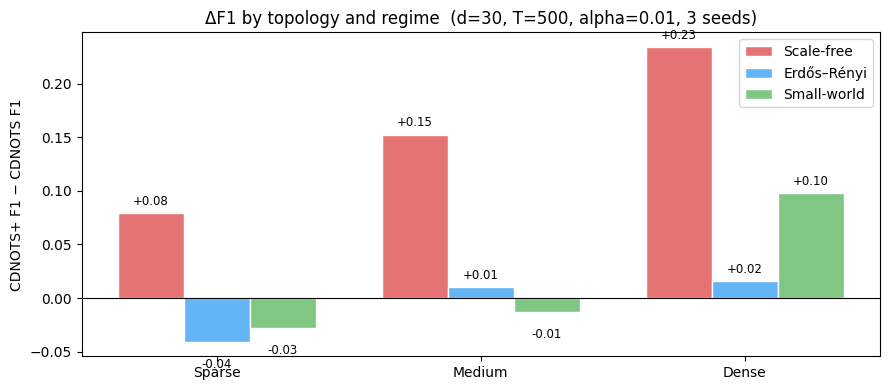

In [ ]:
# Topology sweep: d=30, T=500, 3 seeds, alpha=0.01
topo_configs = [
    ('scale_free',  'sparse', dict(ba_m=2)),
    ('scale_free',  'medium', dict(ba_m=5)),
    ('scale_free',  'dense',  dict(ba_m=8)),
    ('erdos_renyi', 'sparse', dict(er_p=0.05)),
    ('erdos_renyi', 'medium', dict(er_p=0.15)),
    ('erdos_renyi', 'dense',  dict(er_p=0.35)),
    ('small_world', 'sparse', dict(ws_k=2)),
    ('small_world', 'medium', dict(ws_k=4)),
    ('small_world', 'dense',  dict(ws_k=8)),
]

gap_results = {}
for topo, regime, kw in tqdm(topo_configs, desc='topology sweep'):
    gaps = []
    for seed in [0, 1, 2]:  # more seeds for better estimates
        ds = topology_scp(topo, seed=seed, n_vars=30, T=500, max_lag=3, **kw)
        gt = ds['ground_truth']
        ci  = ParCorrGPU(np.zeros((2,2)), device=DEVICE)
        ci2 = ParCorrGPU(np.zeros((2,2)), device=DEVICE)
        f1  = evaluate_graph(run_cdnots(ds['df'], ci, num_lags=3, include_C=False,
                                        alpha=ALPHA, stable=True, show_progress=False
                                        ).cg_tig, gt)['F1']
        f1p = evaluate_graph(run_cdnots_plus(ds['df'], ci2, num_lags=3, include_C=False,
                                             alpha=ALPHA, show_progress=False
                                             ).cg_tig, gt)['F1']
        gaps.append(f1p - f1)
    gap_results[(topo, regime)] = np.mean(gaps)

# Grouped bar chart
topo_colors = {'scale_free': '#E57373', 'erdos_renyi': '#64B5F6', 'small_world': '#81C784'}
topo_labels = {'scale_free': 'Scale-free', 'erdos_renyi': 'Erdős–Rényi', 'small_world': 'Small-world'}
regimes = ['sparse', 'medium', 'dense']
topos   = ['scale_free', 'erdos_renyi', 'small_world']

x = np.arange(len(regimes))
w = 0.25
fig, ax = plt.subplots(figsize=(9, 4))
for i, topo in enumerate(topos):
    vals = [gap_results[(topo, r)] for r in regimes]
    bars = ax.bar(x + i*w, vals, w, label=topo_labels[topo],
                  color=topo_colors[topo], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + (0.005 if v >= 0 else -0.015),
                f'{v:+.2f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=8.5)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + w)
ax.set_xticklabels(['Sparse', 'Medium', 'Dense'])
ax.set_ylabel('CDNOTS+ F1 − CDNOTS F1')
ax.set_title('ΔF1 by topology and regime  (d=30, T=500, alpha=0.01, 3 seeds)')
ax.legend()
plt.tight_layout()
plt.show()

## Finding 3 — The mechanism: power recovery, not false-positive removal

The most counter-intuitive result: **CDNOTS+ does not improve Precision — it improves Recall (TPR)**.

Most users expect the second phase to *remove* spurious edges (↑ Precision). The data shows the opposite:

| Regime | ΔPrecision | **ΔTPR** | ΔF1 |
|---|---|---|---|
| Sparse | −0.049 | **+0.193** | +0.076 |
| Medium | −0.025 | **+0.256** | +0.147 |
| Dense  | −0.005 | **+0.258** | +0.175 |

**Why does PC-style conditioning miss true edges at hub nodes?**

At a hub node with degree 22, the PC skeleton at depth 5 generates
C(21, 5) = **20,349 conditioning sets** per adjacent pair. With T=500 and α=0.01,
statistical power for each individual test collapses. Some conditioning sets will
accidentally make a true edge appear independent — the edge is then wrongly removed.

CDNOTS+ phase 2 re-tests each edge conditioning only on the **discovered parents**
(2–5 variables, not 20,000+). Power is fully restored. True edges are recovered.

> `include_C=False` throughout — this has nothing to do with the nonstationarity
> C node. It is purely a property of hub-graph conditioning set size.

d:   0%|          | 0/2 [00:00<?, ?it/s]

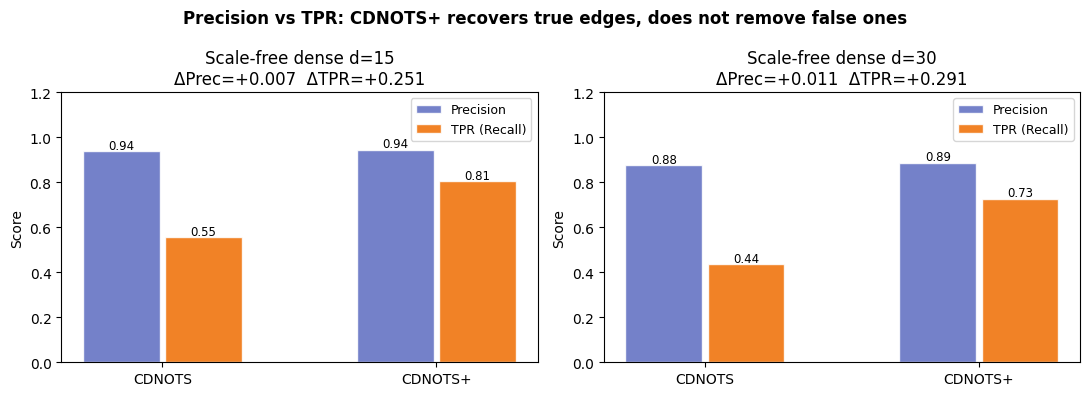

In [13]:
# Precision / TPR breakdown for scale_free dense d=15 and d=30
mech = {d: {m: {'Prec': [], 'TPR': []} for m in ['CDNOTS', 'CDNOTS+']}
        for d in [15, 30]}

for d in tqdm([15, 30], desc='d'):
    ba_m = 8 if d == 15 else 7
    for seed in range(5):
        ds = topology_scp('scale_free', seed=seed, n_vars=d, T=500, max_lag=3, ba_m=ba_m)
        gt = ds['ground_truth']
        ci  = ParCorrGPU(np.zeros((2,2)), device=DEVICE)
        ci2 = ParCorrGPU(np.zeros((2,2)), device=DEVICE)
        m  = evaluate_graph(run_cdnots(ds['df'], ci, num_lags=3, include_C=False,
                                       alpha=ALPHA, stable=True, show_progress=False).cg_tig, gt)
        m2 = evaluate_graph(run_cdnots_plus(ds['df'], ci2, num_lags=3, include_C=False,
                                            alpha=ALPHA, show_progress=False).cg_tig, gt)
        mech[d]['CDNOTS']['Prec'].append(m['Precision'])
        mech[d]['CDNOTS']['TPR'].append(m['TPR'])
        mech[d]['CDNOTS+']['Prec'].append(m2['Precision'])
        mech[d]['CDNOTS+']['TPR'].append(m2['TPR'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metric_colors = {'Prec': '#5C6BC0', 'TPR': '#EF6C00'}
metric_labels = {'Prec': 'Precision', 'TPR': 'TPR (Recall)'}

for ax, d in zip(axes, [15, 30]):
    x = np.arange(2)
    for j, (met, col) in enumerate(metric_colors.items()):
        vals = [np.mean(mech[d][m][met]) for m in ['CDNOTS', 'CDNOTS+']]
        bars = ax.bar(x + j*0.3, vals, 0.28, label=metric_labels[met],
                      color=col, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
                    f'{v:.2f}', ha='center', fontsize=8.5)
    delta_prec = np.mean(mech[d]['CDNOTS+']['Prec']) - np.mean(mech[d]['CDNOTS']['Prec'])
    delta_tpr  = np.mean(mech[d]['CDNOTS+']['TPR'])  - np.mean(mech[d]['CDNOTS']['TPR'])
    ax.set_xticks(x + 0.15)
    ax.set_xticklabels(['CDNOTS', 'CDNOTS+'])
    ax.set_ylim(0, 1.2)
    ax.set_title(f'Scale-free dense d={d}\nΔPrec={delta_prec:+.3f}  ΔTPR={delta_tpr:+.3f}')
    ax.legend(fontsize=9)
    ax.set_ylabel('Score')

plt.suptitle('Precision vs TPR: CDNOTS+ recovers true edges, does not remove false ones',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Finding 4 — Hub degree drives the effect

The power-collapse argument depends on the **hub degree**. The number of conditioning
sets at depth 5 grows exponentially:

| Hub degree | C(degree−1, 5) | Power to survive all tests* |
|---|---|---|
| 5 | 1 | ~0.99 |
| 10 | 126 | ~0.28 |
| 15 | 2,002 | ~2×10⁻⁹ |
| 22 | 20,349 | ~10⁻⁸⁹ |

\* Probability that *none* of the C(d−1,5) tests falsely remove the edge at α=0.01.
Each test has P(no error) ≈ 0.99, so P(all pass) = 0.99^N collapses fast.

At hub degree 22, effectively every true hub edge is removed by PC-style conditioning.
CDNOTS+ parent conditioning (sets of size 2–5) restores P(survive) to ~0.95.

d:   0%|          | 0/2 [00:00<?, ?it/s]

ba_m:   0%|          | 0/5 [00:00<?, ?it/s]

ba_m:   0%|          | 0/5 [00:00<?, ?it/s]

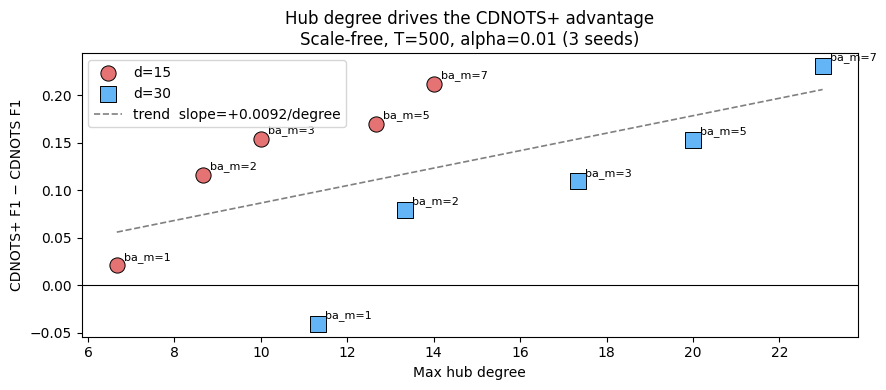

In [18]:
# Hub degree scatter: varying ba_m × n_vars
hub_records = []
for n_vars in tqdm([15, 30], desc='d'):
    for ba_m in tqdm([1, 2, 3, 5, 7], desc='ba_m', leave=False):
        f1_c, f1_p, maxd = [], [], []
        for seed in [0, 1, 2]:
            ds = topology_scp('scale_free', seed=seed, n_vars=n_vars,
                              T=500, max_lag=3, ba_m=ba_m)
            gt = ds['ground_truth']
            maxd.append(ds['meta']['max_degree'])
            ci  = ParCorrGPU(np.zeros((2,2)), device=DEVICE)
            ci2 = ParCorrGPU(np.zeros((2,2)), device=DEVICE)
            f1_c.append(evaluate_graph(run_cdnots(ds['df'], ci, num_lags=3,
                include_C=False, alpha=ALPHA, stable=True, show_progress=False
                ).cg_tig, gt)['F1'])
            f1_p.append(evaluate_graph(run_cdnots_plus(ds['df'], ci2, num_lags=3,
                include_C=False, alpha=ALPHA, show_progress=False
                ).cg_tig, gt)['F1'])
        hub_records.append(dict(n_vars=n_vars, ba_m=ba_m,
                                max_degree=np.mean(maxd),
                                delta=np.mean(f1_p) - np.mean(f1_c)))

df_hub = pd.DataFrame(hub_records)

fig, ax = plt.subplots(figsize=(9, 4))
nv_colors = {15: '#E57373', 30: '#64B5F6'}
nv_markers = {15: 'o', 30: 's'}
for nv in [15, 30]:
    sub = df_hub[df_hub.n_vars == nv]
    ax.scatter(sub['max_degree'], sub['delta'],
               c=nv_colors[nv], marker=nv_markers[nv], s=120,
               edgecolors='black', linewidths=0.7, zorder=4, label=f'd={nv}')
    for _, row in sub.iterrows():
        ax.annotate(f"ba_m={int(row['ba_m'])}",
                    (row['max_degree'], row['delta']),
                    xytext=(5, 4), textcoords='offset points', fontsize=8)

x_all = df_hub['max_degree'].values
y_all = df_hub['delta'].values
c = np.polyfit(x_all, y_all, 1)
xg = np.linspace(x_all.min(), x_all.max(), 100)
ax.plot(xg, np.polyval(c, xg), '--', color='gray', linewidth=1.2,
        label=f'trend  slope={c[0]:+.4f}/degree')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Max hub degree')
ax.set_ylabel('CDNOTS+ F1 − CDNOTS F1')
ax.set_title('Hub degree drives the CDNOTS+ advantage\nScale-free, T=500, alpha=0.01 (3 seeds)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Key takeaways

1. **`alpha=0.01`** is recommended
2. **CDNOTS+ recovers true edges, does not remove false ones** — it is a recall booster
3. **Scale-free hub graphs are the primary beneficiary** — Erdős–Rényi and small-world see no gain
4. **The gain grows with hub degree** — denser scale-free graphs benefit more
